# Import library

In [1]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from utilis import Utility, Data, Visualization, Score
from chunk_handle import get_chunk_indices, iter_chunks, compute_global_image_stats, compute_global_label_stats, save_transform_and_scaler, load_transform_and_scaler

# Build the transform and scaler

interation on the entire dataset one time, to return the mean and stds

In [3]:
# chunk_dir= "./dataset/chunk_kappa_noise_new"
# indices=np.arange(10)
# means, stds=compute_global_image_stats(chunk_dir, indices)
# label_scaler=compute_global_label_stats(chunk_dir, indices)

In [4]:
# from torchvision import transforms
# transform = transforms.Compose([
#     transforms.ToTensor(),     
#     transforms.Normalize(mean=[means], std=[stds]),   
# ])
# print(f"Image stats (from train set): Mean={means}, Std={stds}")
# print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

# save_transform_and_scaler(means, stds, label_scaler, transform_file='./side_module/transform_params.pkl', scaler_file='./side_module/label_scaler.pkl')

# If the transform and scaler is avaiable, ignore that

In [4]:
transform, label_scaler = load_transform_and_scaler(transform_file='./side_module/transform_params.pkl', scaler_file='./side_module/label_scaler.pkl')

Loaded transform with Mean=-0.00016638042870908976, Std=0.02047532983124256
Loaded label scaler with Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


# Model architecture

In [5]:
# Simple CNN architecture for parameter estimation

class Simple_CNN(nn.Module):
    def __init__(self, height, width, num_targets):
        super(Simple_CNN, self).__init__()
        # Convolutional layers
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._feature_size = self._get_conv_output_size(height, width)
        
        # Fully connected layers (regressor head)
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets)
        )

    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.conv_stack(dummy_input)
        return int(np.prod(output.size()))

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.fc_stack(x)
        means = x[:, :2]
        log_sigmas = x[:, 2:]    # Predict log(σ) to ensure positivity
        sigmas = torch.exp(log_sigmas)
        return means, sigmas     # Note that means and sigmas here have to be rescaled properly due to standardization

In [6]:
def KL_div_posterior_loss(pred_means, pred_sigmas, truths):
    """
    A KL divergence loss function that directly optimizes the score function
    
    Inputs:
    - pred_means:   2D tensor (batch_size, 2)
    - pred_sigmas:  2D tensor (batch_size, 2) 
    - truths:       2D tensor (batch_size, 2)
    """
    
    residuals_sq = (pred_means - truths)**2  
    
    loss_terms = residuals_sq / (pred_sigmas**2)
    loss_sum = torch.sum(loss_terms, dim=1)
    
    log_sigma_terms = torch.sum(torch.log(pred_sigmas**2), dim=1)


    loss = torch.mean(loss_sum + log_sigma_terms)
    
    return loss

In [7]:
def KL_div_posterior_loss(pred_means, pred_sigmas, truths):
    """
    A KL divergence loss function that directly optimizes the score function
    
    Inputs:
    - pred_means:   2D tensor (batch_size, 2)
    - pred_sigmas:  2D tensor (batch_size, 2) 
    - truths:       2D tensor (batch_size, 2)
    """
    
    residuals_sq = (pred_means - truths)**2  
    
    loss_terms = residuals_sq / (pred_sigmas**2)
    loss_sum = torch.sum(loss_terms, dim=1)
    
    log_sigma_terms = torch.sum(torch.log(pred_sigmas**2), dim=1)
    loss = torch.mean(loss_sum + log_sigma_terms)
    
    return loss

In [8]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Training")
    for X, y in pbar:
        X, y = X.to(device), y.to(device)

        # Forward pass
        pred_means, pred_sigmas= model(X)
        loss = loss_fn(pred_means, pred_sigmas, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred_means, pred_sigmas = model(X)
            total_loss += loss_fn(pred_means, pred_sigmas, y).item()
            
    return total_loss / len(dataloader)

In [9]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
        if self.transform:
            image = self.transform(image) 
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return image, label
        else:
            return image

In [10]:
import os
import numpy as np
from typing import Optional, Tuple, Generator, Dict, Any
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import time
from tqdm import tqdm
import pickle

class Config:
    IMG_HEIGHT = 1424
    IMG_WIDTH = 176
    
    # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
    NUM_TARGETS = 4

    # Training hyperparameters
    BATCH_SIZE = 128
    EPOCHS = 25
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting
    
    DEVICE = "mps" if torch.has_mps else "cpu"
    MODEL_SAVE_PATH = None  # Will be set dynamically with timestamp

def save_config_and_lr(config: Config, optimizer: optim.Optimizer, config_file: str):
    """
    Save the Config object and the current learning rate of the optimizer.

    Args:
        config: Config object containing training hyperparameters.
        optimizer: PyTorch optimizer with current learning rate.
        config_file: Path to save the config and learning rate.
    """
    # Get current learning rate from optimizer
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save config attributes and learning rate
    config_dict = {
        'IMG_HEIGHT': config.IMG_HEIGHT,
        'IMG_WIDTH': config.IMG_WIDTH,
        'NUM_TARGETS': config.NUM_TARGETS,
        'BATCH_SIZE': config.BATCH_SIZE,
        'EPOCHS': config.EPOCHS,
        'LEARNING_RATE': config.LEARNING_RATE,
        'WEIGHT_DECAY': config.WEIGHT_DECAY,
        'DEVICE': config.DEVICE,
        'MODEL_SAVE_PATH': config.MODEL_SAVE_PATH,
        'current_lr': current_lr
    }
    
    os.makedirs(os.path.dirname(config_file) or '.', exist_ok=True)
    with open(config_file, 'wb') as f:
        pickle.dump(config_dict, f)
    print(f"Saved config and learning rate to {config_file}")

def load_config_and_lr(config_file: str) -> Tuple[Config, float]:
    """
    Load the Config object and the last learning rate for continued training.

    Args:
        config_file: Path to the saved config and learning rate.

    Returns:
        Tuple of (Config object, last learning rate).
    """
    with open(config_file, 'rb') as f:
        config_dict = pickle.load(f)
    
    # Reconstruct Config object
    config = Config()
    config.IMG_HEIGHT = config_dict['IMG_HEIGHT']
    config.IMG_WIDTH = config_dict['IMG_WIDTH']
    config.NUM_TARGETS = config_dict['NUM_TARGETS']
    config.BATCH_SIZE = config_dict['BATCH_SIZE']
    config.EPOCHS = config_dict['EPOCHS']
    config.LEARNING_RATE = config_dict['LEARNING_RATE']
    config.WEIGHT_DECAY = config_dict['WEIGHT_DECAY']
    config.DEVICE = config_dict['DEVICE']
    config.MODEL_SAVE_PATH = config_dict['MODEL_SAVE_PATH']
    current_lr = config_dict['current_lr']
    
    print(f"Loaded config from {config_file}")
    print(f"Loaded learning rate: {current_lr}")
    return config, current_lr

def incremental_train(model: nn.Module, 
                      config: Config,
                      optimizer: optim.Optimizer, 
                      criterion: nn.Module, 
                      chunk_dir: str,
                      split_ratio: float = 0.8,
                      epochs_per_chunk: int = 1,
                      device: str = 'mps' if torch.has_mps else 'cpu',
                      verbose: bool = False,
                      log_file: str = None,
                      config_file: str = None) -> Dict[str, Any]:
    """
    Incrementally train a PyTorch model across chunks without loading the entire dataset.
    
    - Loads one chunk at a time.
    - Splits each chunk into train/test sets.
    - Trains the model on the train set using batches (for memory efficiency within chunk).
    - Validates once per epoch using concatenated validation data from all chunks.
    - Logs training progress to a text file.
    - Uses tqdm for progress visualization.
    - Saves config and final learning rate in a single timestamped folder.
    - Returns a summary dict with loss history, etc.
    
    Args:
        model: PyTorch model (nn.Module).
        optimizer: PyTorch optimizer.
        criterion: Loss function (e.g., nn.MSELoss()).
        chunk_dir: Directory containing chunk files.
        split_ratio: Fraction for train split (e.g., 0.8).
        epochs_per_chunk: Number of epochs to train on each chunk.
        device: Device to train on ('cuda' or 'cpu').
        verbose: If True, print additional progress details.
        log_file: Path to the text file for logging training progress (set dynamically if None).
        config_file: Path to save the config and learning rate (set dynamically if None).
    
    Returns:
        Dict with 'train_losses' (list of lists: per-chunk losses), 'total_epochs', etc.
    """
    # Generate a fixed timestamp for this training run
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    
    # Set file paths using the fixed timestamp
    model_dir = f"./side_module/model_{timestamp}"
    if log_file is None:
        log_file = f"{model_dir}/training_log.txt"
    if config_file is None:
        config_file = f"{model_dir}/training_config.pkl"
    config.MODEL_SAVE_PATH = f"{model_dir}/best_model.pth"

    # Initialize log file (overwrite if exists)
    os.makedirs(os.path.dirname(log_file) or '.', exist_ok=True)
    with open(log_file, 'w') as f:
        f.write("Training Log\n")
        f.write(f"Started at {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Config: EPOCHS={config.EPOCHS}, BATCH_SIZE={config.BATCH_SIZE}, LEARNING_RATE={config.LEARNING_RATE}, DEVICE={config.DEVICE}, MODEL_SAVE_PATH={config.MODEL_SAVE_PATH}\n\n")

    device = config.DEVICE
    model.to(device)
    model.train()
    total_val_datasets = []
    
    indices = get_chunk_indices(chunk_dir)
    train_losses = []  # List of lists: losses per epoch per chunk
    val_losses = []  # List of validation losses per epoch  
    total_samples = 0
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    best_val_loss = float('inf')
    start_time = time.time()

    for epoch in tqdm(range(config.EPOCHS), desc="Epochs", leave=True):
        with open(log_file, 'a') as f:
            f.write(f"Epoch {epoch+1}/{config.EPOCHS}\n")
        epoch_train_losses = []
        
        for chunk_idx in tqdm(indices, desc="Chunks", leave=False):
            if verbose:
                print(f"Processing chunk {chunk_idx}...")
            with open(log_file, 'a') as f:
                f.write(f"  Processing chunk {chunk_idx}...\n")
            
            # Load single chunk (assumes it fits in memory)
            noisy_chunk, label_chunk, _ = next(iter_chunks(chunk_dir, indices=[chunk_idx]))
            
            # Split into train/test (stratified if labels are categorical; here simple split)
            Nsys = noisy_chunk.shape[1]
            if verbose:
                print(f"NP_idx : {Nsys}")
            NP_idx = np.arange(Nsys)   
            shape = noisy_chunk.shape[2:]
            if verbose:
                print('n samples in chunk (H,W):', shape)
            split_fraction = 1 - split_ratio
            seed = 113

            train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction, random_state=seed)

            noisy_kappa_train = noisy_chunk[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), 1424, 176)
            label_train = label_chunk[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
            noisy_kappa_val = noisy_chunk[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), 1424, 176)
            label_val = label_chunk[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)

            Ntrain = label_train.shape[0] * label_train.shape[1]
            Nval = label_val.shape[0] * label_val.shape[1]
            if verbose:
                print(f'Shape of the split training data = {noisy_kappa_train.shape}')
                print(f'Shape of the split validation data = {noisy_kappa_val.shape}')
                print(f'Shape of the split training labels = {label_train.shape}')
                print(f'Shape of the split validation labels = {label_val.shape}')

            # Reshape the data for CNN
            X_train = noisy_kappa_train.reshape(Ntrain, *shape)
            X_val = noisy_kappa_val.reshape(Nval, *shape)

            # Keep only the first 2 cosmological parameters
            label_dim = label_train.shape[2]
            y_train = label_train.reshape(Ntrain, label_dim)[:, :2]
            y_val = label_val.reshape(Nval, label_dim)[:, :2]

            # Label standardization
            y_train_scaled = label_scaler.transform(y_train)
            y_val_scaled = label_scaler.transform(y_val)
            if verbose:
                print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

            train_dataset = CosmologyDataset(data=X_train, labels=y_train_scaled, transform=transform)
            val_dataset = CosmologyDataset(data=X_val, labels=y_val_scaled, transform=transform)
            
            if epoch == 0:
                total_val_datasets.append(val_dataset)

            train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)

            for epoch_chunk in range(epochs_per_chunk):
                train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
                epoch_train_losses.append(train_loss)
                if verbose:
                    print(f"  Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f}")
                with open(log_file, 'a') as f:
                    f.write(f"    Epoch {epoch_chunk+1}/{epochs_per_chunk} | Train Loss: {train_loss:.6f}\n")

        train_losses.append(epoch_train_losses)

        # Validate once per epoch using concatenated validation dataset
        if epoch == 0:
            all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
            all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
            concatenated_val_dataset = CosmologyDataset(
                data=all_val_data,
                labels=all_val_labels,
                transform=transform
            )
            val_loader = DataLoader(
                concatenated_val_dataset,
                batch_size=config.BATCH_SIZE,
                shuffle=False
            )

        val_loss = validate_epoch(model, val_loader, criterion, config.DEVICE)
        val_losses.append(val_loss) 
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}/{config.EPOCHS} | Avg Train Loss: {np.mean(epoch_train_losses):.6f} | Val Loss: {val_loss:.6f}")
        with open(log_file, 'a') as f:
            f.write(f"Epoch {epoch+1}/{config.EPOCHS} | Avg Train Loss: {np.mean(epoch_train_losses):.6f} | Val Loss: {val_loss:.6f}\n")

        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            print(f"  -> New best model saved to {config.MODEL_SAVE_PATH}")
            with open(log_file, 'a') as f:
                f.write(f"  -> New best model saved to {config.MODEL_SAVE_PATH} (Val Loss: {val_loss:.6f})\n")

    # Save config and final learning rate
    save_config_and_lr(config, optimizer, config_file)

    end_time = time.time()
    total_time_min = (end_time - start_time) / 60
    print(f"\nTraining finished in {total_time_min:.2f} minutes.")
    with open(log_file, 'a') as f:
        f.write(f"\nTraining finished in {total_time_min:.2f} minutes.\n")

    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
    return {
        'train_losses': train_losses,
        'total_val_datasets': total_val_datasets,
        'total_epochs': config.EPOCHS,
        'total_samples': total_samples,
        'val_losses': val_losses    
    }

/var/folders/5q/5ly3gv3n277dm7hdjp89npfc0000gn/T/ipykernel_54995/2961757491.py:27: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  DEVICE = "mps" if torch.has_mps else "cpu"
/var/folders/5q/5ly3gv3n277dm7hdjp89npfc0000gn/T/ipykernel_54995/2961757491.py:98: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device: str = 'mps' if torch.has_mps else 'cpu',


In [11]:
# Training script
config = Config()
model = Simple_CNN(config.IMG_HEIGHT, config.IMG_WIDTH, config.NUM_TARGETS)  # Replace with your model class
pretrain = False
previous_path = None  # Set to the timestamp of the previous run if pretrain=True, e.g., '20250918_144500'

if pretrain:
    if previous_path is None:
        raise ValueError("Please specify previous_timestamp for pretraining (e.g., '20250918_144500').")
    config_file = f'{previous_path}/training_config.pkl'
    config, last_lr = load_config_and_lr(config_file=config_file)
    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
    optimizer = optim.Adam(model.parameters(), lr=last_lr, weight_decay=config.WEIGHT_DECAY)
else:
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

criterion = KL_div_posterior_loss  # Replace with your criterion

# Continue training
result = incremental_train(
    model=model,
    config=config,
    optimizer=optimizer,
    criterion=criterion,
    chunk_dir='./dataset/chunk_kappa_noise_new',
    split_ratio=0.8,
    epochs_per_chunk=1,
    verbose=True
)

Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Processing chunk 0...
NP_idx : 11
n samples in chunk (H,W): (1424, 176)
Shape of the split training data = (101, 8, 1424, 176)
Shape of the split validation data = (101, 3, 1424, 176)
Shape of the split training labels = (101, 8, 5)
Shape of the split validation labels = (101, 3, 5)
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]










Training: 100%|██████████| 7/7 [00:05<00:00,  1.27it/s]


  Epoch 1/1 | Train Loss: 8.610082
Processing chunk 1...
NP_idx : 11
n samples in chunk (H,W): (1424, 176)
Shape of the split training data = (101, 8, 1424, 176)
Shape of the split validation data = (101, 3, 1424, 176)
Shape of the split training labels = (101, 8, 5)
Shape of the split validation labels = (101, 3, 5)
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]









Training: 100%|██████████| 7/7 [00:01<00:00,  3.72it/s]


...

  Epoch 1/1 | Train Loss: -2.563497
Processing chunk 24...
NP_idx : 10
n samples in chunk (H,W): (1424, 176)
Shape of the split training data = (101, 8, 1424, 176)
Shape of the split validation data = (101, 2, 1424, 176)
Shape of the split training labels = (101, 8, 5)
Shape of the split validation labels = (101, 2, 5)
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]










Training: 100%|██████████| 7/7 [00:02<00:00,  3.33it/s]


  Epoch 1/1 | Train Loss: -2.935584


Epochs: 100%|██████████| 25/25 [35:21<00:00, 84.85s/it]


Epoch 25/25 | Avg Train Loss: -3.229278 | Val Loss: -0.911005
Saved config and learning rate to ./side_module/model_20250918_153642/training_config.pkl

Training finished in 35.36 minutes.


In [12]:
# config = Config()
# model=Simple_CNN(config.IMG_HEIGHT, config.IMG_WIDTH, config.NUM_TARGETS)
# model.load_state_dict(torch.load("/Users/viethuy/Working_space/Neurips/Neurips2025_Weak_lensing/best_model.pth", weights_only=True)) # Directly load the best model
# optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

# criterion = KL_div_posterior_loss  # Custom loss function defined earlier
# # criterion = nn.MSELoss()  # Mean Squared Error loss for regression
# history = incremental_train(model, config, optimizer, criterion, './dataset', epochs_per_chunk=1, verbose=False)

In [14]:
total_val_datasets = result['total_val_datasets']
train_losses = result['train_losses']
total_samples = result['total_samples']
total_epochs = result['total_epochs']
if total_val_datasets:
    all_val_data = np.concatenate([ds.data for ds in total_val_datasets], axis=0)
    all_val_labels = np.concatenate([ds.labels for ds in total_val_datasets], axis=0)
    concatenated_val_dataset = CosmologyDataset(
        data=all_val_data,
        labels=all_val_labels,
        transform=transform # Use transform from first dataset
    )
    val_loader = DataLoader(
        concatenated_val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )
else:
    concatenated_val_loader = None
    print("No validation datasets to concatenate.")

In [15]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for X, _ in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean_val = np.concatenate(means_pred_list, axis=0)
mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

Validating: 100%|██████████| 45/45 [00:05<00:00,  8.53it/s]


In [16]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean_val - errorbar_val < 0
errorbar_val[negative_mask] = mean_val[negative_mask]

In [17]:
validation_score = Score._score_phase1(
    true_cosmo=all_val_labels,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))

averaged score: -5384.507895351114
averaged error bar: [0.03911373 0.02881585]


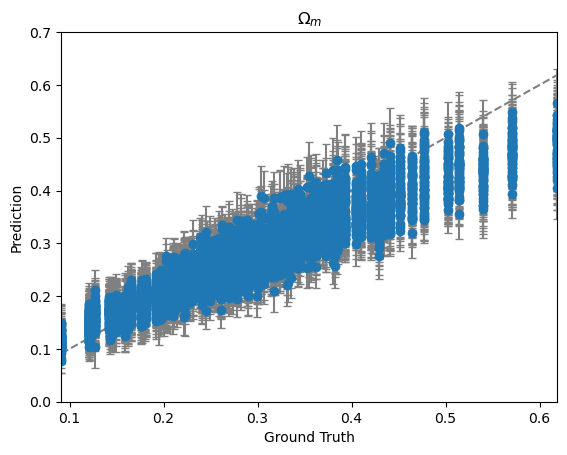

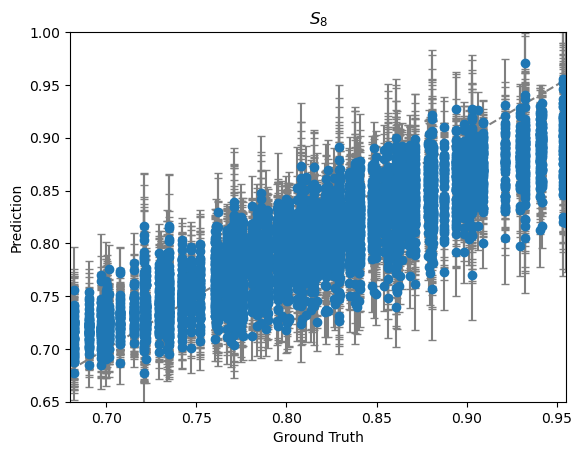

In [18]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels
all_val_labels_inv = label_scaler.inverse_transform(all_val_labels)
plt.errorbar(all_val_labels_inv[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels_inv[:,0]), sorted(all_val_labels_inv[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels_inv[:,0]), np.max(all_val_labels_inv[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(all_val_labels_inv[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(all_val_labels_inv[:,1]), sorted(all_val_labels_inv[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(all_val_labels_inv[:,1]), np.max(all_val_labels_inv[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [19]:
# Initialize Data class object
data_obj = Data(data_dir="./dataset", USE_PUBLIC_DATASET=True)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

Loading WIDE12H_bin2_2arcmin_kappa.npy: 100%|██████████| 11/11 [00:43<00:00,  4.00s/it]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy: 100%|██████████| 40/40 [00:05<00:00,  7.37it/s]


In [20]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [21]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [22]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for X in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean = np.concatenate(means_pred_list, axis=0)
mean = label_scaler.inverse_transform(mean)          # inverse transform

errorbar = np.concatenate(sigmas_pred_list, axis=0)
errorbar = errorbar*label_scaler.var_**0.5           # rescale by the training label std

Inference on the test set: 100%|██████████| 32/32 [00:05<00:00,  5.79it/s]


In [23]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean - errorbar < 0
errorbar[negative_mask] = mean[negative_mask]

In [24]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_25-09-18-16-13.zip


In [25]:
# model.eval()
# means_pred_list, sigmas_pred_list = [], []
# pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
# with torch.no_grad():
#     for X, _ in pbar:
#         X = X.to(config.DEVICE)
#         means_pred, sigmas_pred = model(X)         
#         means_pred_list.append(means_pred.cpu().numpy()) 
#         sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
# mean_val = np.concatenate(means_pred_list, axis=0)
# mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

# errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
# errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

In [26]:
# model.eval()
# means_pred_list, sigmas_pred_list = [], []
# pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
# with torch.no_grad():
#     for X, _ in pbar:
#         X = X.to(config.DEVICE)
#         means_pred, sigmas_pred = model(X)         
#         means_pred_list.append(means_pred.cpu().numpy()) 
#         sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
# mean_val = np.concatenate(means_pred_list, axis=0)
# mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

# errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
# errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std